# LAB 05 — Linear Regression: Predicting House Prices

## Student Information
**Name:** Faryal Gul

**Student ID:** 023-24-0014

**Section:** BSCS AI SECTION-B

**GitHub:**

**Kaggle:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/submissions

**Dataset:** House Prices — Advanced Regression Techniques

**Dataset Source:** Kaggle — https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Linear Regression theory. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> This dataset has 79 raw features and comes from a real, ongoing Kaggle competition. Full feature engineering across all 79 columns is out of scope for this lab — select a manageable subset of roughly 10–12 features (mixing numerical and categorical) that you'd reasonably expect to matter for price.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [5]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error


---

## 1. Problem Definition

Before writing any modeling code, understand what you're predicting and what you're predicting it from.

**Tasks**
1. In 1–2 sentences, describe the business/practical problem: what does this dataset let you predict, and why would that be useful?
2. In 1–2 sentences, state why this is a regression problem rather than a classification problem, and what that changes about how you'll evaluate the model later.

**Answer 1:**
The main problem is to predict the price of a house based on its different features, such as overall quality, living area, total basement area, year built, and other house details. This can be useful for estimating house prices and helping buyers, sellers, or real estate businesses make better decisions.


**Answer 2:**
The main problem is to predict the price of a house based on its different features, such as living area, quality, year built, and other house details. This can be useful for estimating house prices and helping buyers, sellers, or real estate businesses make better decisions.


---

## 2. Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df.head()`, `df.describe()`

**Task**
3. Load `train.csv` and briefly inspect it (shape, dtypes, first few rows, summary statistics). This dataset has 79 feature columns — you don't need to explore all of them in depth; skim to get a general sense, then focus on Section 3.

In [6]:
# Task 3 — load and inspect the dataset
df=pd.read_csv("train.csv")
print(df.shape)
df.info()
print(df.head())
print(df.describe())


(1460, 81)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallC

**Observations:**
_(what did you notice about the data — size, ranges, any obvious oddities?)_ The dataset contains 1,460 houses and 81 columns, including numerical and categorical features. There are some missing values in several columns such as LotFrontage, Alley, MasVnrType, BsmtQual and the SalePrice ranges from 34,900 to 755,000, showing that house prices vary widely. Some features also contain zero values such as PoolArea, WoodDeckSF etc  which may indicate that a house does not have that particular feature.


---

## 3. Feature and Target Identification

**Task**
4. Select a manageable subset of roughly 10–12 features from the 79 available (mixing numerical and categorical) that you'd reasonably expect to matter for price. Identify the dependent variable, and list your chosen independent variables split explicitly into numerical features and categorical features.

**Answer 4:**

Dependent variable: SalePrice

Numerical independent variables: OverallQual, GrLivArea, GarageCars, TotalBsmtSF, FullBath, TotRmsAbvGrd, YearBuilt, Fireplaces

Categorical independent variables: ExterQuality, KitchenQual, BsmtQual, Neighborhood

---

## 4. Data Preparation

scikit-learn's `LinearRegression` requires fully numeric input. Convert categorical columns appropriately.

*Concepts/functions you may find useful:* `df[col].map({'yes': 1, 'no': 0})`, `pd.get_dummies(df, columns=[...])`

**Tasks**
5. Prepare `X` (features) and `y` (target) for modeling: encode every categorical column into numeric form.
6. Briefly justify your choice of encoding method for each type of column.
7. Confirm `X` is fully numeric with no missing values.

In [7]:
# Task 5 — define X and y, encode categorical columns
y=df["SalePrice"]
features=[ "OverallQual", "GrLivArea","GarageCars","TotalBsmtSF","FullBath","TotRmsAbvGrd","YearBuilt","Fireplaces","ExterQual","KitchenQual","BsmtQual","Neighborhood"]
x=df[features]
x=pd.get_dummies(x,columns=["ExterQual","KitchenQual","BsmtQual","Neighborhood"],drop_first=True)




In [8]:
# Task 7 — confirm X is fully numeric with no missing values
x=x.astype(int)
print(x.dtypes)
print("Missing value : ",x.isnull().sum())


OverallQual             int64
GrLivArea               int64
GarageCars              int64
TotalBsmtSF             int64
FullBath                int64
TotRmsAbvGrd            int64
YearBuilt               int64
Fireplaces              int64
ExterQual_Fa            int64
ExterQual_Gd            int64
ExterQual_TA            int64
KitchenQual_Fa          int64
KitchenQual_Gd          int64
KitchenQual_TA          int64
BsmtQual_Fa             int64
BsmtQual_Gd             int64
BsmtQual_TA             int64
Neighborhood_Blueste    int64
Neighborhood_BrDale     int64
Neighborhood_BrkSide    int64
Neighborhood_ClearCr    int64
Neighborhood_CollgCr    int64
Neighborhood_Crawfor    int64
Neighborhood_Edwards    int64
Neighborhood_Gilbert    int64
Neighborhood_IDOTRR     int64
Neighborhood_MeadowV    int64
Neighborhood_Mitchel    int64
Neighborhood_NAmes      int64
Neighborhood_NPkVill    int64
Neighborhood_NWAmes     int64
Neighborhood_NoRidge    int64
Neighborhood_NridgHt    int64
Neighborho

**Answer 6 (encoding justification):**
Numerical features were kept as they were because they were already in numeric form. Categorical features were converted using one-hot encoding with pd.get_dummies() because these categories do not have a natural numerical order. This converts each category into separate 0/1 columns and makes the data suitable for Linear Regression.

---

## 5. Train/Test Split

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=...)`

**Task**
8. Split `X` and `y` into training and test sets (e.g. an 80/20 split) and report the resulting shapes.

In [10]:
# Task 8 — train/test split, report shapes
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("x_train shape : ",x_train.shape)
print("x_test shape : ",x_test.shape)
print("y_train shape : ",y_train.shape)
print("y_test shape : ",y_test.shape)

x_train shape :  (1168, 41)
x_test shape :  (292, 41)
y_train shape :  (1168,)
y_test shape :  (292,)


---

## 6. Linear Regression Model

*Concepts/functions you may find useful:* `LinearRegression()`, `.fit(X_train, y_train)`

**Task**
9. Train a `LinearRegression` model on the training data.

In [11]:
# Task 9 — train the Linear Regression model
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


---

## 7. Predictions

*Concepts/functions you may find useful:* `.predict(X)`

**Task**
10. Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10 test houses.

In [12]:
# Task 10 — generate predictions, compare actual vs predicted
y_pred=model.predict(x_test)
comparison=pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})
print(comparison.head(10))

   Actual Price  Predicted Price
0        154500    133501.413460
1        325000    352576.635361
2        115000    118314.153607
3        159000    182280.703993
4        315500    314106.554292
5         75500     58026.036485
6        311500    231629.273451
7        146000    152619.369855
8         84500     57613.933908
9        135500    116726.679499


**Task 10 — Actual vs. Predicted (sample of 10)**

| Actual Price | Predicted Price |
|--------------|-----------------|
| 154500       | 133501.413460   |
| 325000       | 352576.635361   |
| 115000       | 118314.153607   |
| 159000       | 182280.703993   |
| 315500       | 314106.554292   |
| 75500        | 58026.036485    |
| 311500       | 231629.273451   |
| 146000       | 152619.369855   |
| 84500        | 57613.933908    |
| 135500       | 116726.679499   |

---

## 8. Coefficients and Intercept

*Concepts/functions you may find useful:* `model.intercept_`, `model.coef_`, `pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})`

**Tasks**
11. Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation, with a one-line, plain-English interpretation for each feature.
12. Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

In [16]:
# Task 11 — extract intercept and coefficients
print("Intercept : ",model.intercept_)
coefficients=pd.DataFrame({
    "Feature " : x.columns, "Coefficient " : model.coef_
})
print(coefficients)

Intercept :  -350105.46656838804
                Feature   Coefficient 
0            OverallQual  11094.911816
1              GrLivArea     35.530892
2             GarageCars  11108.969158
3            TotalBsmtSF     17.957899
4               FullBath   1024.735364
5           TotRmsAbvGrd   1243.356773
6              YearBuilt    206.051288
7             Fireplaces   8787.329994
8           ExterQual_Fa -21436.647572
9           ExterQual_Gd -19182.874012
10          ExterQual_TA -17881.520355
11        KitchenQual_Fa -39977.621738
12        KitchenQual_Gd -29634.018844
13        KitchenQual_TA -40182.248990
14           BsmtQual_Fa -22069.790106
15           BsmtQual_Gd -24074.391111
16           BsmtQual_TA -21849.674406
17  Neighborhood_Blueste -10296.029195
18   Neighborhood_BrDale -10591.851640
19  Neighborhood_BrkSide  16849.584539
20  Neighborhood_ClearCr  49176.541699
21  Neighborhood_CollgCr  26405.053962
22  Neighborhood_Crawfor  40681.523144
23  Neighborhood_Edwards   2212

**Task 11 — Coefficient Table**

| Feature | Coefficient | Interpretation |
|---|---:|---|
| OverallQual | 11094.91 | A 1-point increase in overall quality is associated with about $11,094.91 higher predicted price, holding other features constant. |
| GrLivArea | 35.53 | A 1-unit increase in living area is associated with about $35.53 higher predicted price, holding other features constant. |
| GarageCars | 11108.97 | One additional garage-car capacity is associated with about $11,108.97 higher predicted price, holding other features constant. |
| TotalBsmtSF | 17.96 | A 1-unit increase in basement area is associated with about $17.96 higher predicted price, holding other features constant. |
| FullBath | 1024.74 | One additional full bathroom is associated with about $1,024.74 higher predicted price, holding other features constant. |
| TotRmsAbvGrd | 1243.36 | One additional room above ground is associated with about $1,243.36 higher predicted price, holding other features constant. |
| YearBuilt | 206.05 | A 1-year increase in the year built is associated with about $206.05 higher predicted price, holding other features constant. |
| Fireplaces | 8787.33 | One additional fireplace is associated with about $8,787.33 higher predicted price, holding other features constant. |
| ExterQual_Fa | -21436.65 | Compared with the reference exterior-quality category, Fa is associated with about $21,436.65 lower predicted price, holding other features constant. |
| ExterQual_Gd | -19182.87 | Compared with the reference exterior-quality category, Gd is associated with about $19,182.87 lower predicted price, holding other features constant. |
| ExterQual_TA | -17881.52 | Compared with the reference exterior-quality category, TA is associated with about $17,881.52 lower predicted price, holding other features constant. |
| KitchenQual_Fa | -39977.62 | Compared with the reference kitchen-quality category, Fa is associated with about $39,977.62 lower predicted price, holding other features constant. |
| KitchenQual_Gd | -29634.02 | Compared with the reference kitchen-quality category, Gd is associated with about $29,634.02 lower predicted price, holding other features constant. |
| KitchenQual_TA | -40182.25 | Compared with the reference kitchen-quality category, TA is associated with about $40,182.25 lower predicted price, holding other features constant. |
| BsmtQual_Fa | -22069.79 | Compared with the reference basement-quality category, Fa is associated with about $22,069.79 lower predicted price, holding other features constant. |
| BsmtQual_Gd | -24074.39 | Compared with the reference basement-quality category, Gd is associated with about $24,074.39 lower predicted price, holding other features constant. |
| BsmtQual_TA | -21849.67 | Compared with the reference basement-quality category, TA is associated with about $21,849.67 lower predicted price, holding other features constant. |
| Neighborhood_Blueste | -10296.03 | Compared with the reference neighborhood, Blueste is associated with about $10,296.03 lower predicted price, holding other features constant. |
| Neighborhood_BrDale | -10591.85 | Compared with the reference neighborhood, BrDale is associated with about $10,591.85 lower predicted price, holding other features constant. |
| Neighborhood_BrkSide | 16849.58 | Compared with the reference neighborhood, BrkSide is associated with about $16,849.58 higher predicted price, holding other features constant. |
| Neighborhood_ClearCr | 49176.54 | Compared with the reference neighborhood, ClearCr is associated with about $49,176.54 higher predicted price, holding other features constant. |
| Neighborhood_CollgCr | 26405.05 | Compared with the reference neighborhood, CollgCr is associated with about $26,405.05 higher predicted price, holding other features constant. |
| Neighborhood_Crawfor | 40681.52 | Compared with the reference neighborhood, Crawfor is associated with about $40,681.52 higher predicted price, holding other features constant. |
| Neighborhood_Edwards | 2212.03 | Compared with the reference neighborhood, Edwards is associated with about $2,212.03 higher predicted price, holding other features constant. |
| Neighborhood_Gilbert | 17794.29 | Compared with the reference neighborhood, Gilbert is associated with about $17,794.29 higher predicted price, holding other features constant. |
| Neighborhood_IDOTRR | 7428.75 | Compared with the reference neighborhood, IDOTRR is associated with about $7,428.75 higher predicted price, holding other features constant. |
| Neighborhood_MeadowV | 1104.13 | Compared with the reference neighborhood, MeadowV is associated with about $1,104.13 higher predicted price, holding other features constant. |
| Neighborhood_Mitchel | 12117.92 | Compared with the reference neighborhood, Mitchel is associated with about $12,117.92 higher predicted price, holding other features constant. |
| Neighborhood_NAmes | 13044.83 | Compared with the reference neighborhood, NAmes is associated with about $13,044.83 higher predicted price, holding other features constant. |
| Neighborhood_NPkVill | 1878.86 | Compared with the reference neighborhood, NPkVill is associated with about $1,878.86 higher predicted price, holding other features constant. |
| Neighborhood_NWAmes | 14560.72 | Compared with the reference neighborhood, NWAmes is associated with about $14,560.72 higher predicted price, holding other features constant. |
| Neighborhood_NoRidge | 79406.75 | Compared with the reference neighborhood, NoRidge is associated with about $79,406.75 higher predicted price, holding other features constant. |
| Neighborhood_NridgHt | 46628.58 | Compared with the reference neighborhood, NridgHt is associated with about $46,628.58 higher predicted price, holding other features constant. |
| Neighborhood_OldTown | 2923.57 | Compared with the reference neighborhood, OldTown is associated with about $2,923.57 higher predicted price, holding other features constant. |
| Neighborhood_SWISU | 9207.59 | Compared with the reference neighborhood, SWISU is associated with about $9,207.59 higher predicted price, holding other features constant. |
| Neighborhood_Sawyer | 15913.92 | Compared with the reference neighborhood, Sawyer is associated with about $15,913.92 higher predicted price, holding other features constant. |
| Neighborhood_SawyerW | 15595.14 | Compared with the reference neighborhood, SawyerW is associated with about $15,595.14 higher predicted price, holding other features constant. |
| Neighborhood_Somerst | 29913.51 | Compared with the reference neighborhood, Somerst is associated with about $29,913.51 higher predicted price, holding other features constant. |
| Neighborhood_StoneBr | 66142.94 | Compared with the reference neighborhood, StoneBr is associated with about $66,142.94 higher predicted price, holding other features constant. |
| Neighborhood_Timber | 31720.06 | Compared with the reference neighborhood, Timber is associated with about $31,720.06 higher predicted price, holding other features constant. |
| Neighborhood_Veenker | 58472.09 | Compared with the reference neighborhood, Veenker is associated with about $58,472.09 higher predicted price, holding other features constant. |

**Answer 12:**
The intercept does not have a sensible real-world interpretation because it represents the predicted house price when all features are zero. A real house cannot realistically have all these features equal to zero, so the intercept mainly acts as a mathematical starting point for the Linear Regression model.


---

## 9. Residual Analysis

*Concepts/functions you may find useful:* `residuals = y_test - y_pred`, `plt.scatter(y_pred, residuals)`, `plt.hist(residuals, bins=...)`

**Task**
13. Compute residuals on the test set and plot them (e.g. residuals vs. predicted values, and a histogram of residuals). Do the residuals look randomly scattered, or is there a visible pattern?

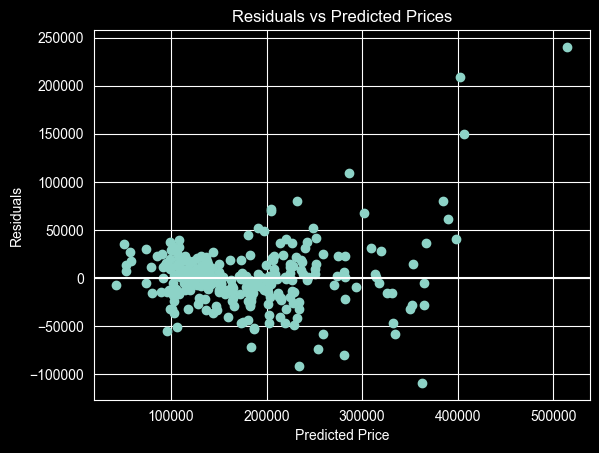

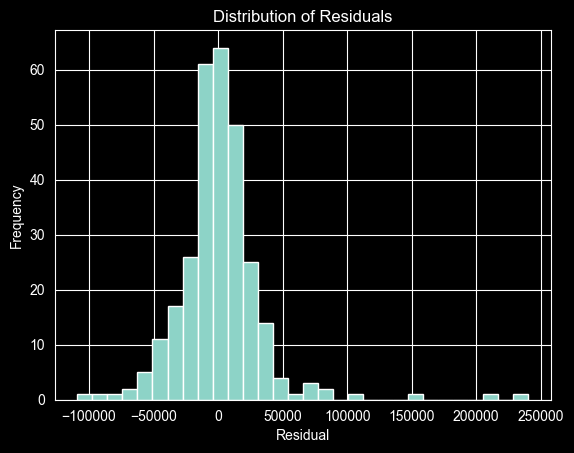

In [17]:
# Task 13 — compute and plot residuals
residuals=y_test - y_pred
# Residuals vs predicted values
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Prices")
plt.axhline(y=0)
plt.show()

# Histogram of residuals
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

**Answer 13:**
The residuals are mostly centered around zero, but they are not completely randomly scattered. The spread of residuals increases for higher predicted prices, and some large residuals are also present. The histogram shows that most residuals are close to zero, but there are a few large positive residuals. This suggests that the model has some prediction errors, especially for higher-priced houses.

---

## 10. Regression Metrics

*Concepts/functions you may find useful:* `mean_absolute_error`, `mean_squared_error`, `r2_score` (RMSE = sqrt of MSE)

**Tasks**
14. Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.
15. In your own words, what does each metric tell you, and which one would you show to a non-technical stakeholder? Why?

In [20]:
# Task 14 — compute MAE, MSE, RMSE, R² on the test set
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test, y_pred)
print("mean_absolute error : ",mae)
print("mean_squared error : ",mse)
print("root mean square error : ",rmse)
print("r2 score : ",r2)


mean_absolute error :  21083.979224921037
mean_squared error :  1132500721.4626083
root mean square error :  33652.64806018404
r2 score :  0.8523529911411785


**Task 14 — Test Set Metrics**

| Metric | Value          |
|---|----------------|
| MAE | 21083.979      |
| MSE | 1132500721.462 |
| RMSE | 33652.648      |
| R² | 0.85235299     |

**Answer 15:**
MAE tells us the average difference between the actual and predicted house prices. In our model, the MAE is about $21,083.98, which means the predictions are off by about $21,084 on average. MSE measures the average squared error and gives more importance to large errors. RMSE is the square root of MSE and shows the prediction error in the same unit as the house price. Our RMSE is about $33,652.65. R² tells us how much of the variation in house prices is explained by the model. Our R² is 0.8524, which means the model explains about 85.24% of the variation in house prices. For a non-technical stakeholder, I would show MAE because it is easy to understand and directly tells the average prediction error.

---

## 11. Training vs Testing Performance

*Concepts/functions you may find useful:* `model.predict(X_train)`, comparing metrics computed on train vs. test

**Tasks**
16. Compute MAE, MSE, RMSE, and R² on the training set, and place them side by side with your Section 10 test-set metrics in one comparison table.
17. Is there a large gap between training and testing performance? What would a large gap suggest about overfitting or generalization, and what does your actual result suggest here?

In [22]:
# Task 16 — compute training-set metrics
train_pred=model.predict(x_train)
train_mae=mean_absolute_error(y_train, train_pred)
train_mse=mean_squared_error(y_train, train_pred)
train_rmse=np.sqrt(train_mse)
train_r2=r2_score(y_train, train_pred)
print("train_mae : ",train_mae)
print("train_mse : ",train_mse)
print("tarin rmse : ",train_rmse)
print("train_r2 : ",train_r2)



train_mae :  20076.861325858586
train_mse :  1013755785.6078025
tarin rmse :  31839.531805725448
train_r2 :  0.8300365122162303


**Task 16 — Train vs. Test Comparison**

| Metric | Training Set   | Test Set       |
|---|----------------|----------------|
| MAE | 20076.8613     | 21083.979      |
| MSE | 1013755785.607 | 1132500721.462 |
| RMSE | 31839.5318     | 33652.648      |
| R² | 0.83003651     | 0.85235299     |

**Answer 17:**
There is no large gap between the training and test performance. The MAE and RMSE are slightly higher on the test set, while the R² is slightly higher on the test set. This shows that the model performs similarly on both datasets and does not show a clear sign of overfitting. It suggests that the model is generalizing reasonably well to unseen data.

---

## 12. Model Interpretation

**Task**
18. Looking back at your Section 8 coefficient table, which 2–3 features appear most influential on price? Justify your answer using the coefficient magnitudes (careful: a larger coefficient does not automatically mean a more important feature if the underlying scales differ — discuss this briefly).

**Answer 18:**
Based on the coefficient magnitudes, Neighborhood_NoRidge, Neighborhood_StoneBr, and Neighborhood_Veenker appear to have the strongest influence on predicted house price. Their coefficients are approximately 79,406.75, 66,142.94, and 58,472.09, respectively. These positive coefficients mean that, compared with the reference neighborhood, these neighborhoods are associated with higher predicted prices, while keeping other features constant. However, coefficient size alone does not always show true feature importance because the features have different scales and some are categorical dummy variables. Therefore, these coefficients should be interpreted carefully rather than assuming they are the three most important features overall.

---

## 13. Conclusion

**Tasks**
19. Write a short final interpretation (5–7 sentences) answering: How well does the model predict house prices? Which metric is most useful and why? Which feature has the strongest effect? What limitations does Linear Regression have for this dataset? What would you try next?
20. Apply the same feature selection and encoding you used on `train.csv` to `test.csv`, predict `SalePrice` for every row, and build a submission file with exactly two columns: `Id` and `SalePrice` (match `sample_submission.csv`'s format). Save it as `submission.csv`.
21. Submit `submission.csv` on the competition's "Submit Predictions" page. Record your public leaderboard score and rank below.

**Answer 19 — Conclusion:**
The Linear Regression model predicts house prices reasonably well, with an R² score of 0.8524 on the test set. The model explains about 85.24% of the variation in house prices, while the MAE shows that the predictions are off by about $21,084 on average. MAE is the most useful metric for a non-technical stakeholder because it is easy to understand and directly shows the average prediction error. Based on the coefficient magnitudes, Neighborhood_NoRidge has the strongest effect in our selected features, with a coefficient of about $79,406.75. However, Linear Regression may not capture complex or non-linear relationships between house features and prices. The residual plots also showed some pattern and larger errors for higher predicted prices. As a next step, I would try a more advanced model such as Random Forest and compare its performance with Linear Regression.

In [34]:
# Task 20 — apply encoding to test.csv, predict SalePrice, build submission.csv
test_df=pd.read_csv("test.csv")
print(test_df.shape)
print(test_df.head())
features=["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF","FullBath", "TotRmsAbvGrd", "YearBuilt", "Fireplaces",
"ExterQual", "KitchenQual", "BsmtQual", "Neighborhood"]
test_x=test_df[features]
print(test_x.shape)
print(test_x.head())
test_x=pd.get_dummies(
    test_x,
    columns=["ExterQual", "KitchenQual", "BsmtQual", "Neighborhood"],
    drop_first=True
)
test_x=test_x.reindex(columns=x.columns, fill_value=0)
print(test_x.shape)
print(test_x.isnull().sum().sum())
print(test_x.isnull().sum()[test_x.isnull().sum() > 0])
print(test_df.loc[test_x["GarageCars"].isnull(), ["Id", "GarageCars"]])
print(test_df.loc[test_x["TotalBsmtSF"].isnull(), ["Id", "TotalBsmtSF"]])
test_x["GarageCars"]=test_x["GarageCars"].fillna(x["GarageCars"].median())
test_x["TotalBsmtSF"]=test_x["TotalBsmtSF"].fillna(x["TotalBsmtSF"].median())
print(test_x.isnull().sum().sum())
test_pred=model.predict(test_x)

print(test_pred.shape)
print(test_pred[:10])
house_price_submission=pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_pred
})

print(house_price_submission.head())
print(house_price_submission.shape)
house_price_submission.to_csv("house_price_submission.csv", index=False)
# verifying
print(house_price_submission.head())
print(house_price_submission.shape)
print(house_price_submission.columns)

(1459, 80)
     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0  1461          20       RH         80.0    11622   Pave   NaN      Reg   
1  1462          20       RL         81.0    14267   Pave   NaN      IR1   
2  1463          60       RL         74.0    13830   Pave   NaN      IR1   
3  1464          60       RL         78.0     9978   Pave   NaN      IR1   
4  1465         120       RL         43.0     5005   Pave   NaN      IR1   

  LandContour Utilities  ... ScreenPorch PoolArea PoolQC  Fence MiscFeature  \
0         Lvl    AllPub  ...         120        0    NaN  MnPrv         NaN   
1         Lvl    AllPub  ...           0        0    NaN    NaN        Gar2   
2         Lvl    AllPub  ...           0        0    NaN  MnPrv         NaN   
3         Lvl    AllPub  ...           0        0    NaN    NaN         NaN   
4         HLS    AllPub  ...         144        0    NaN    NaN         NaN   

  MiscVal MoSold  YrSold  SaleType  SaleCondition  
0    

**Answer 21 — Kaggle Leaderboard Result:**

Public score: 	0.16498

Rank: 2562

Reflection (1–2 sentences):  I applied Linear Regression on the Ames Housing dataset
using carefully selected numerical features (OverallQual, GrLivArea,
GarageCars, TotalBsmtSF, etc.) and categorical quality features
(ExterQual, KitchenQual, Neighborhood). After log-transforming the
target variable and encoding categorical features, my model achieved
a public RMSLE score of 0.16498, placing me at rank 2562 on the
leaderboard. This demonstrates that feature selection plays a crucial
role in model performance, and even a simple Linear Regression model
can perform well with the right features.

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Exploration
- [ ] Section 3 — Feature and Target Identification
- [ ] Section 4 — Data Preparation (encoding justified)
- [ ] Section 5 — Train/Test Split
- [ ] Section 6 — Linear Regression Model
- [ ] Section 7 — Predictions (actual vs. predicted table)
- [ ] Section 8 — Coefficients and Intercept (full table + interpretation)
- [ ] Section 9 — Residual Analysis (plots + discussion)
- [ ] Section 10 — Regression Metrics (MAE, MSE, RMSE, R²)
- [ ] Section 11 — Training vs Testing Performance (comparison table + discussion)
- [ ] Section 12 — Model Interpretation (most influential features)
- [ ] Section 13 — Conclusion, submission.csv generated, and submitted to the Kaggle competition (score/rank recorded)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted